# Modelatge
En aquest notebook aplicarem models d'aprenentatge no supervisats de clustering per agrupar els barris segons les seves característiques. 

**to do**
- Preprocess
    - StandardScaler
    - PCA
- Models
    - Kmeans
    - DBSCAN
    - AglomerativeClustering
- Conclusions i resultats

**Funcions a definir:**
- funcio per gràficar pca i variança explicada
- funcio per silouette i inercia
- funcio per kmeans i graficar clusters
- funcio per agglomerative i graficar clusters
- funcio per silouette i inercia





# Llibreries i configuracio

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

sns.set_theme()

# Carrega dels datasets

In [31]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'


df_2015 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR / 'modelling' / 'df_deltes.csv')

# Emagatzemem en un diccionari per treballar més eficient

datasets = {
    "2015": df_2015,
    "2023": df_2023,
    "Deltes": df_deltes
}

print("Dataset 2015: ", df_2015.shape)
print("Dataset 2023: ", df_2023.shape)
print("Dataset Deltes: ", df_deltes.shape)

Dataset 2015:  (73, 14)
Dataset 2023:  (73, 14)
Dataset Deltes:  (73, 14)


# Funcions auxiliars 

In [88]:
def extreure_codi_barri(df:pd.DataFrame): 
    codi_barri = df["codi_barri"]
    X = df[[col for col in df.columns if col != "codi_barri"]].copy()
    return codi_barri, X

def grafic_var_explicada(pca: np.array, target: float, titol: str, nom_arxiu: str):
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= target) + 1
    var_explicada = pca.explained_variance_ratio_
    
    plt.figure(figsize=(8,4))
    plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, label="Var Explicada")
    plt.plot(range(1, len(var_explicada)+1), cumsum, linewidth=1, marker = 'o', label= "Var Explicada Cum",c ="r")
    plt.axhline(0.95, color='green', linestyle='--', label='95%')
    plt.plot([n_components, n_components], [0, target], "k:")
    plt.plot([0, n_components], [target, target], "k:")
    plt.plot(n_components, target, "ko")
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"{titol}")
    plt.legend()
    plt.savefig(RESULTS_DIR / f"{nom_arxiu}")
    plt.show()

# Preprocessament
- Separar variables de codi_barri
- Escalar els conjunts de dades

In [32]:
# Separem la columna de codi barri
codi_barri_15, X_15 = extreure_codi_barri(df_2015)
codi_barri_23, X_23 = extreure_codi_barri(df_2023)
codi_barri_deltes, X_deltes = extreure_codi_barri(df_deltes)

In [33]:
# Escalem les dades
scaler = StandardScaler()

X_15_scaled = scaler.fit_transform(X_15)
X_23_scaled = scaler.fit_transform(X_23)
X_deltes_scaled = scaler.fit_transform(X_deltes)

In [12]:
pd.DataFrame(X_15_scaled, columns=[col for col in df_2015.columns if col != "codi_barri"], index = codi_barri_15).head()

,poblacio_total,pct_pob_estrangera,pct_pob_estrangera_occidental,pct_joves,pct_universitaris,import_euros,index_gini,total_incidents_1000_hab,locals_restauracio_1000_hab,locals_sanitaris_1000_hab,locals_serveis_professionals_1000_hab,preu_mitja_m2,pisos_turistics_1000_hab
codi_barri,,,,,,,,,,,,,
1,1.748498,4.199298,1.234963,2.639910,-0.338881,-1.325308,0.983481,-0.428328,1.294698,-0.872398,-0.478502,0.360589,0.062359
2,-0.449368,3.409486,4.159846,3.397023,0.999060,-0.626203,2.468153,0.016741,5.822851,-0.693779,-0.997270,0.410255,1.778386
3,-0.482507,2.030912,2.662939,2.177334,-0.070818,-0.775703,0.550981,0.027236,1.909879,-0.245979,-0.891861,2.943221,0.226881
4,0.033751,3.063875,3.787288,2.857088,0.907440,-0.568757,1.976707,-0.221923,2.356379,-0.533351,-0.094821,1.155245,0.871703
5,0.664571,0.494933,0.730770,0.467236,0.822564,0.323664,0.258840,-0.366979,0.043057,-0.286575,0.955075,0.261257,1.567595


# PCA (Principal Component analysis)

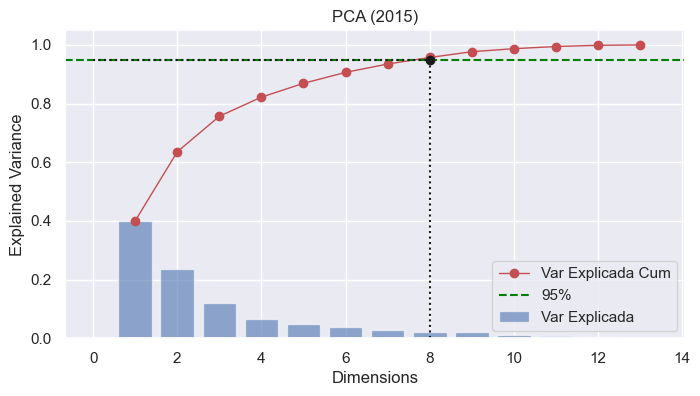

In [89]:
# Probarem PCA per reduir la dimensionalitat del conjunt de dades
pca_15 = PCA(random_state= 42)
pca_embedding = pca_15.fit_transform(X_15_scaled)
grafic_var_explicada(pca_15, 0.95, "PCA (2015)", "variança_explicada_15.png")

**Observacions:**
- Per al dataset de 2015, el nombre de components que expliquen una variança superior o igual al 95% és 8, mentre que amb 5 ja podem explicar el 90% de la variança.

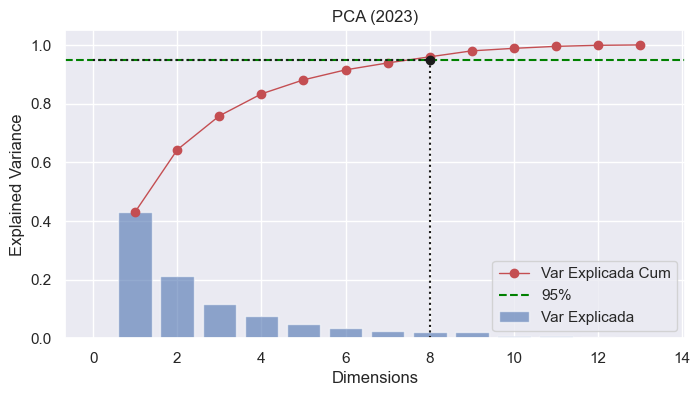

In [90]:
pca_23 = PCA(random_state= 42)
pca_embedding = pca_23.fit_transform(X_23_scaled)
grafic_var_explicada(pca_23, 0.95, "PCA (2023)", "variança_explicada_23.png")

**Observacions:**
- Per al dataset de 2023 el nombre de dimensions necessari per explicar el 95% de la variança són 8

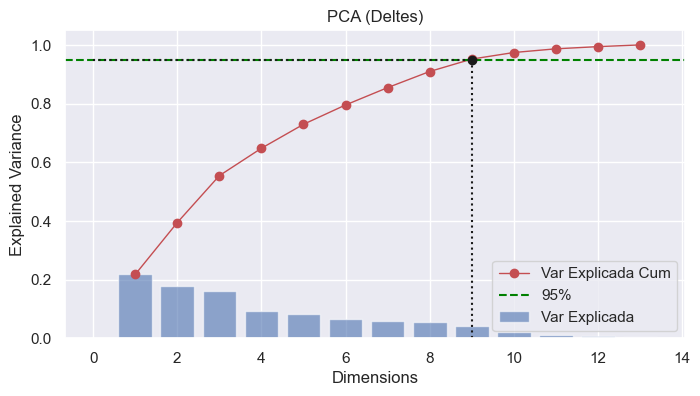

In [91]:
pca_deltes = PCA(random_state= 42)
pca_embedding = pca_deltes.fit_transform(X_deltes_scaled)
grafic_var_explicada(pca_deltes, 0.95, "PCA (Deltes)", "variança_explicada_deltes.png")

**Observacions:**
- Per al dataset de Deltes el nombre de dimensions necessari per explicar el 95% de la variança són 9 components